In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [4]:
def remove_nan_rows(df):
    """
    Removes rows from the DataFrame that contain any NaN values.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame.

    Returns:
    pandas.DataFrame: The DataFrame with rows containing NaN values removed.
    """
    return df.dropna()

In [5]:
my_colors = gu.ksha_color_set_summon(color_set=0)
red = my_colors['red']
blue = my_colors['blue']
orange = my_colors['orange']

# line specs
line_keys = {}
#line_keys['xxx'] = {'linewidth': 3, 'linestyle': '--', 'color': blue, 'alpha': 1, 'zorder': 2, 'label': ''}
line_keys['train'] = {'linewidth': 3, 'linestyle': '-', 'color': orange, 'alpha': 1, 'zorder': 3, 'label': 'train'}
line_keys['valid'] = {'linewidth': 3, 'linestyle': '--', 'color': red, 'alpha': 1, 'zorder': 4, 'label': 'valid'}

In [6]:
# log_path1 = '/glade/work/ksha/DWC_runs/FE_large/training_hist/training_log.csv' 

# varname_base = 'u'
# for ilev in range(4):
#     varname = varname_base + f'_{ilev}'
    
#     logs1 = pd.read_csv(log_path1)
#     logs1 = remove_nan_rows(logs1)
    
#     train_mae1 = np.array(logs1[f'train_rmse_{varname}'])
#     valid_mae1 = np.array(logs1[f'valid_rmse_{varname}'])
#     # mae_tendency = np.mean(np.abs(np.diff(valid_mae1)))
    
#     L1 = np.arange(len(train_mae1))

#     # detrend_mae = signal.detrend(valid_mae1)
#     # mae_std = np.std(detrend_mae)
    
#     fig = plt.figure(figsize=(7, 4))
#     ax = fig.gca()
#     ax = gu.ax_decorate_box(ax)
#     ax.tick_params(labelleft=True, labelbottom=True, labelsize=14)
#     ax.grid(':')
    
#     ax.plot(L1[2:], train_mae1[2:], **line_keys['train'])
#     ax.plot(L1[2:], valid_mae1[2:], **line_keys['valid'])
    
#     plt.legend(fontsize=14)
#     ax.set_xlabel('Epochs', fontsize=14)
#     ax.set_ylabel('RMSE', fontsize=14)
#     ax.set_title(f'MAE validation loss\nvarname: {varname}', fontsize=14);

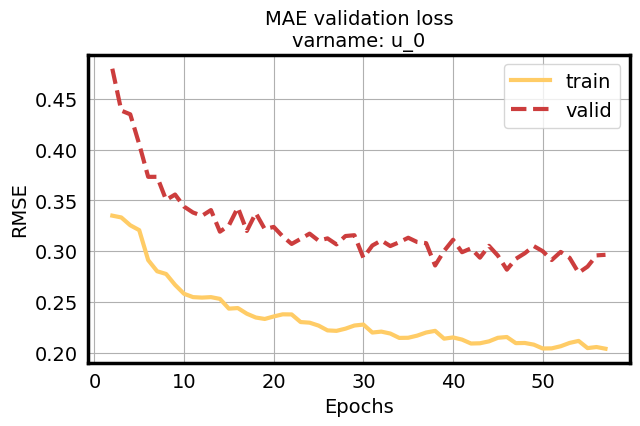

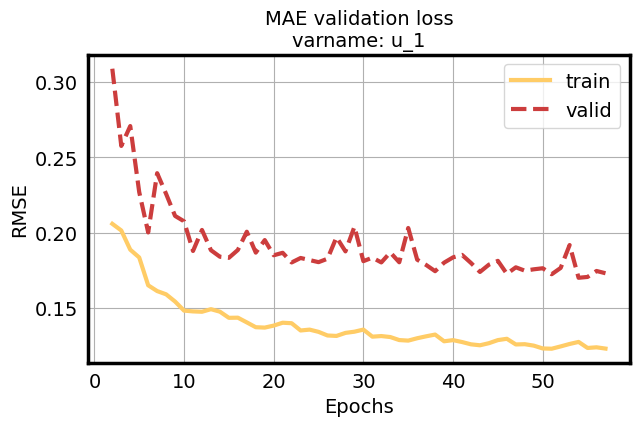

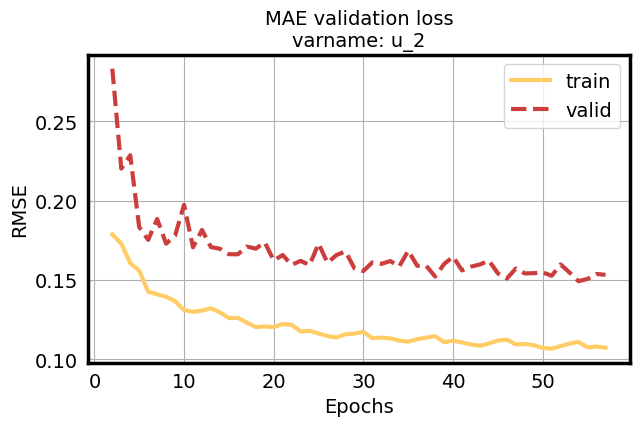

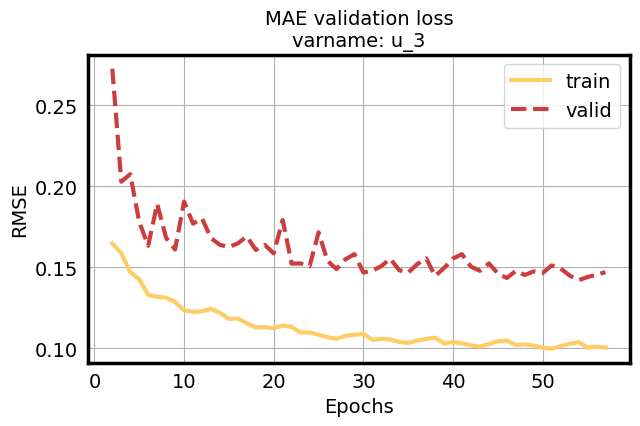

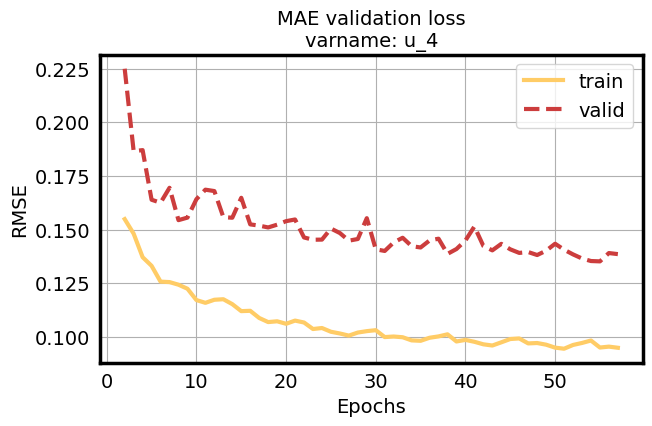

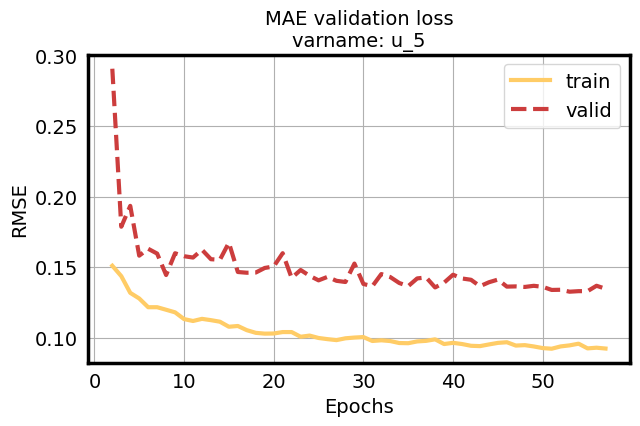

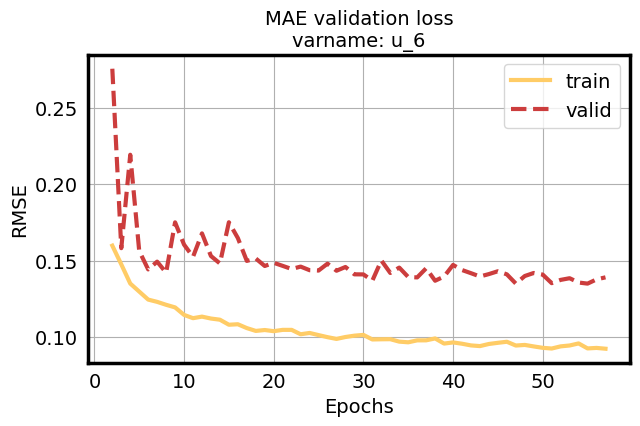

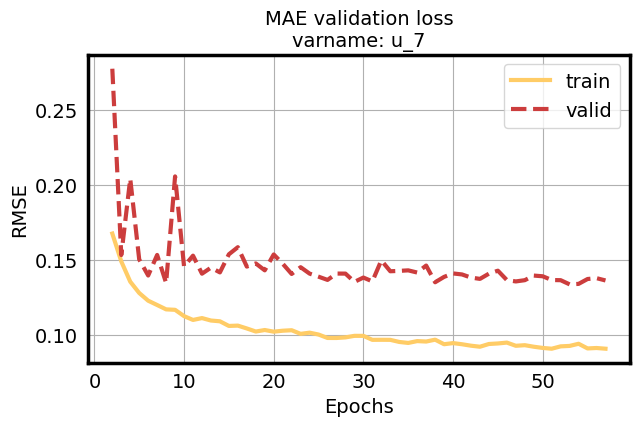

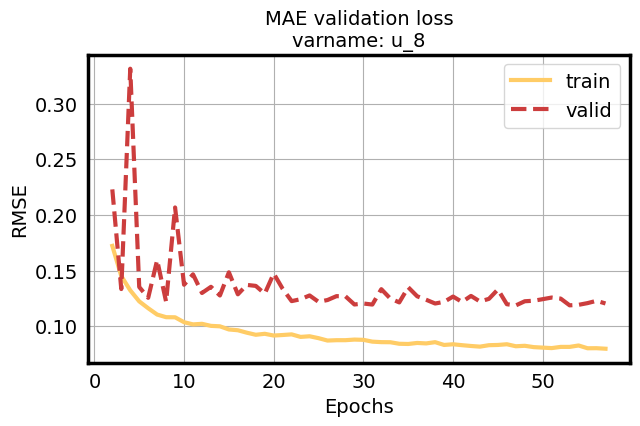

In [7]:
# log_path1 = '/glade/work/ksha/DWC_runs/FE_new/training_log.csv' 
log_path1 = '/glade/work/ksha/DWC_runs/FE_bond/training_log.csv' 

varname_base = 'u'
for ilev in range(9):
    varname = varname_base + f'_{ilev}'
    
    logs1 = pd.read_csv(log_path1)
    logs1 = remove_nan_rows(logs1)
    
    train_mae1 = np.array(logs1[f'train_rmse_{varname}'])
    valid_mae1 = np.array(logs1[f'valid_rmse_{varname}'])
    # mae_tendency = np.mean(np.abs(np.diff(valid_mae1)))
    
    L1 = np.arange(len(train_mae1))

    # detrend_mae = signal.detrend(valid_mae1)
    # mae_std = np.std(detrend_mae)
    
    fig = plt.figure(figsize=(7, 4))
    ax = fig.gca()
    ax = gu.ax_decorate_box(ax)
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=14)
    ax.grid(':')
    
    ax.plot(L1[2:], train_mae1[2:], **line_keys['train'])
    ax.plot(L1[2:], valid_mae1[2:], **line_keys['valid'])
    
    plt.legend(fontsize=14)
    ax.set_xlabel('Epochs', fontsize=14)
    ax.set_ylabel('RMSE', fontsize=14)
    ax.set_title(f'MAE validation loss\nvarname: {varname}', fontsize=14);

In [17]:
# log_path1 = '/glade/campaign/ral/hap/ksha/DWC_runs/CONUS_GP_clean/training_log.csv'

# logs1 = pd.read_csv(log_path1)
# logs1 = remove_nan_rows(logs1)

# train_mae1 = np.array(logs1['train_rmse'])
# valid_mae1 = np.array(logs1['valid_rmse'])
# L1 = np.arange(len(train_mae1))

# log_path2 = '/glade/work/ksha/DWC_runs/CONUS_GP_ERA5_L/training_log.csv'
# logs2 = pd.read_csv(log_path2)
# logs2 = remove_nan_rows(logs2)
# train_mae2 = np.array(logs2['train_rmse'])
# valid_mae2 = np.array(logs2['valid_rmse'])
# L2 = np.arange(len(train_mae2))

# fig = plt.figure(figsize=(7, 4))
# ax = fig.gca()
# ax = gu.ax_decorate_box(ax)
# ax.tick_params(labelleft=True, labelbottom=True, labelsize=14)
# ax.grid(':')

# # ax.plot(L1, train_mae1, **line_keys['train'])
# ax.plot(L1, valid_mae1, **line_keys['valid'])

# plt.legend(fontsize=14)
# ax.set_xlabel('Epochs', fontsize=14)
# ax.set_ylabel('RMSE', fontsize=14)
# # ax.set_title('DWC Great Plain domain foundation model\nAll variable averaged training and validation RMSE', fontsize=14)

In [10]:
varnames = ['WRF_T2', 'WRF_U10', 'WRF_V10', 'WRF_T_4', 'WRF_Q_tot_05_4']
dict_RMSE1 = {}

base_dir = '/glade/work/ksha/DWC_runs/CONUS_GP_clean/forecasts/metrics/'

fn_verif = sorted(glob(base_dir+'*.csv'))

for varname in varnames:
    rmse_list = []
    fn = fn_verif[0]
    metrics = pd.read_csv(fn)
    rmse_ = metrics[f'rmse_{varname}'].values
    rmse_list.append(rmse_.reshape((-1, 8784)))
    
    rmse_all = np.concatenate(rmse_list, axis=0)
    rmse_clean = np.unique(rmse_all, axis=0)
    rmse_clean_mean = rmse_clean.mean(axis=0)
    dict_RMSE1[varname] = rmse_clean_mean
    #print(rmse_clean_mean[:12])

In [11]:
#varnames = ['WRF_SP', 'WRF_T2', 'WRF_U10', 'WRF_precip', 'WRF_PWAT']
dict_RMSE2 = {}

# base_dir = '/glade/campaign/ral/hap/ksha/DWC_runs/CONUS_GP_ERA5_20250629/forecasts_ERA5_48/metrics/'
# base_dir = '/glade/work/ksha/DWC_runs/CONUS_GP_ERA5/forecasts_single/metrics/'
base_dir = '/glade/work/ksha/DWC_runs/CONUS_GP_clean/forecasts_single_final/metrics/'
fn_verif = sorted(glob(base_dir+'*.csv'))

for varname in varnames:
    # if varname == 'WRF_PWAT':
    #     varname_open = 'WRF_column_total_moisture'
    # elif varname == 'WRF_Q_4':
    #     varname_open = 'WRF_Q_2'
    # else:
    varname_open = varname
        
    rmse_list = []
    fn = fn_verif[0]
    metrics = pd.read_csv(fn)
    rmse_ = metrics[f'rmse_{varname_open}'].values
    rmse_list.append(rmse_.reshape((-1, 8784)))
    
    rmse_all = np.concatenate(rmse_list, axis=0)
    rmse_clean = np.unique(rmse_all, axis=0)
    rmse_clean_mean = rmse_clean.mean(axis=0)
    dict_RMSE2[varname] = rmse_clean_mean

In [12]:
leads1 = np.arange(1, 8785, 1)
leads2 = np.arange(1, 8785, 1)

In [13]:
# ds_WRF = xr.open_dataset('/glade/campaign/ral/hap/ksha/DWC/GATHER/CONUS_GP/2020-01-02T00Z.nc')
# WRF_P = ds_WRF['WRF_P'].isel(time=0).mean(['longitude', 'latitude']).values

In [14]:

# fig, axs = plt.subplots(3, 2, figsize=(13, 10))
# AX = axs.ravel()
# plt.tight_layout(w_pad=3, h_pad=3)

# for i_var, varname in enumerate(varnames):
#     ax = AX[i_var]
#     ax = gu.ax_decorate_box(ax)
#     ax.tick_params(labelleft=True, labelbottom=True, labelsize=14)
#     ax.grid(':')
#     ax.plot(leads2[:], dict_RMSE2[varname][:], **line_keys['train'])
#     ax.plot(leads1[:], dict_RMSE[varname][:], **line_keys['valid'])
#     ax.set_title('Var name: {}'.format(varname), fontsize=14)
    
#     if i_var == 0:
#         ax.set_ylabel('RMSE', fontsize=14)
        
#     if i_var == 4 or i_var == 5:
#         ax.set_xlabel('Forecast lead time [hour]', fontsize=14)
#         plt.legend(fontsize=14)

In [15]:
my_colors = gu.ksha_color_set_summon(color_set=0)
red = my_colors['red']
blue = my_colors['blue']
orange = my_colors['orange']

# line specs
line_keys = {}
#line_keys['xxx'] = {'linewidth': 3, 'linestyle': '--', 'color': blue, 'alpha': 1, 'zorder': 2, 'label': ''}
line_keys['train'] = {'linewidth': 3, 'linestyle': '-', 'color': orange, 'alpha': 1, 'zorder': 3, 'label': 'Last time'}
line_keys['valid'] = {'linewidth': 3, 'linestyle': '--', 'color': red, 'alpha': 1, 'zorder': 4, 'label': 'Now'}

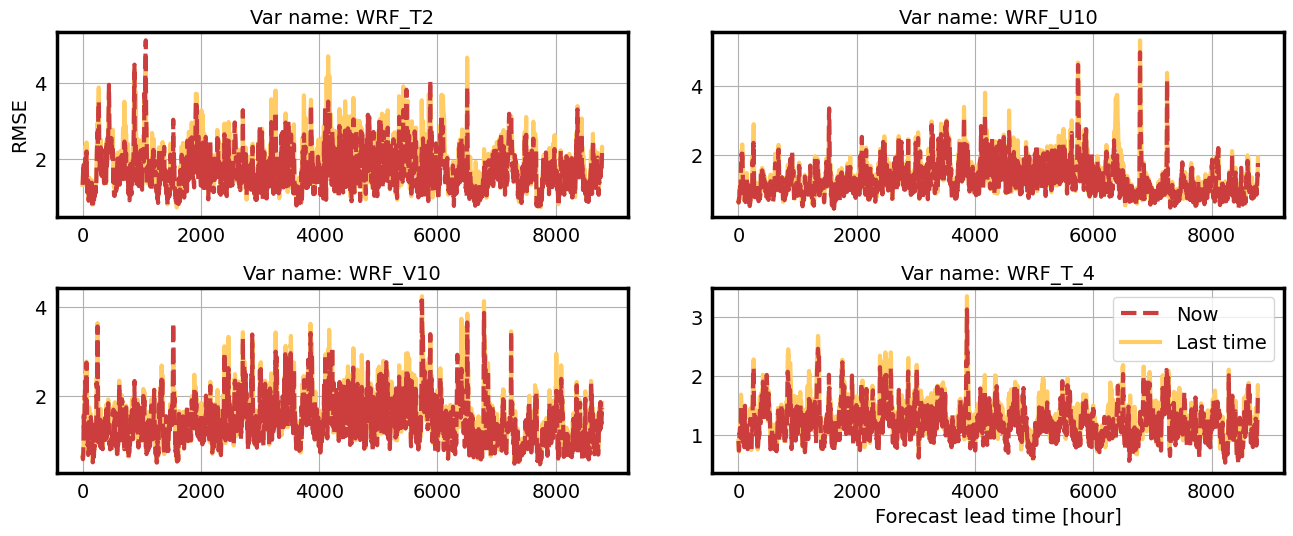

In [19]:
cut = 0
cut1 = None

fig, axs = plt.subplots(2, 2, figsize=(13, 5))
AX = axs.ravel()
plt.tight_layout(w_pad=3, h_pad=3)

for i_var, varname in enumerate(varnames[:4]):
    ax = AX[i_var]
    ax = gu.ax_decorate_box(ax)
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=14)
    ax.grid(':')
    ax.plot(leads1[cut:cut1], dict_RMSE1[varname][cut:cut1], **line_keys['valid'])
    ax.plot(leads2[cut:cut1], dict_RMSE2[varname][cut:cut1], **line_keys['train'])
    ax.set_title('Var name: {}'.format(varname), fontsize=14)
    
    if i_var == 0:
        ax.set_ylabel('RMSE', fontsize=14)
        
    if i_var == 3:
        ax.set_xlabel('Forecast lead time [hour]', fontsize=14)
        plt.legend(fontsize=14)
        

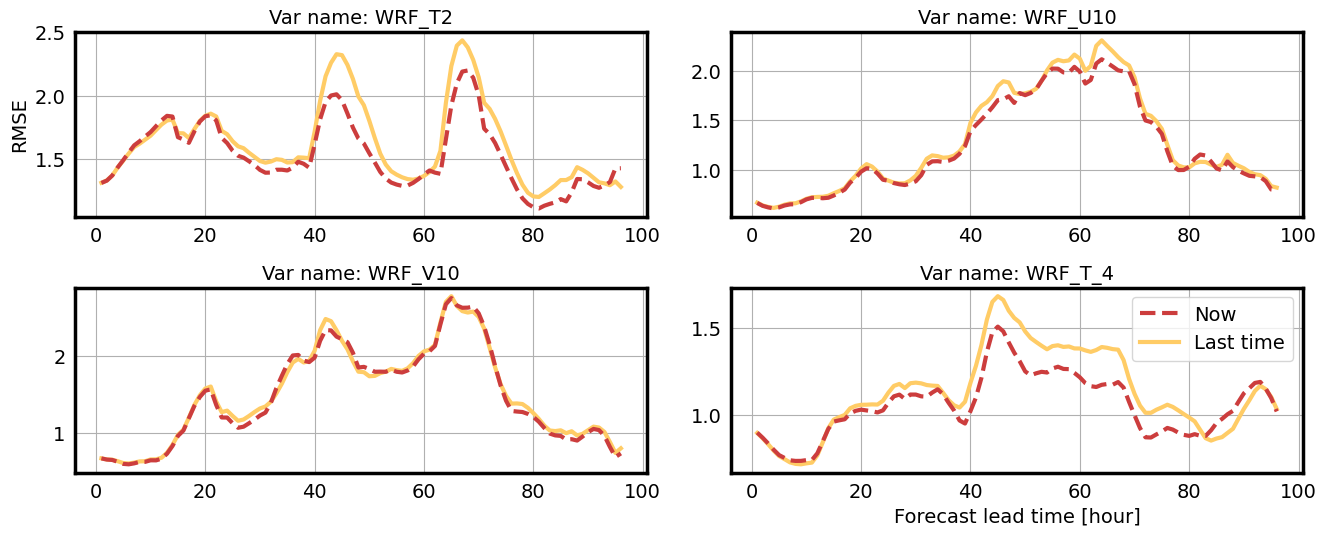

In [17]:
cut = 0
cut1 = 96

fig, axs = plt.subplots(2, 2, figsize=(13, 5))
AX = axs.ravel()
plt.tight_layout(w_pad=3, h_pad=3)

for i_var, varname in enumerate(varnames[:4]):
    ax = AX[i_var]
    ax = gu.ax_decorate_box(ax)
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=14)
    ax.grid(':')
    ax.plot(leads1[cut:cut1], dict_RMSE1[varname][cut:cut1], **line_keys['valid'])
    ax.plot(leads2[cut:cut1], dict_RMSE2[varname][cut:cut1], **line_keys['train'])
    
    ax.set_title('Var name: {}'.format(varname), fontsize=14)
    
    if i_var == 0:
        ax.set_ylabel('RMSE', fontsize=14)
        
    if i_var == 3:
        ax.set_xlabel('Forecast lead time [hour]', fontsize=14)
        plt.legend(fontsize=14)

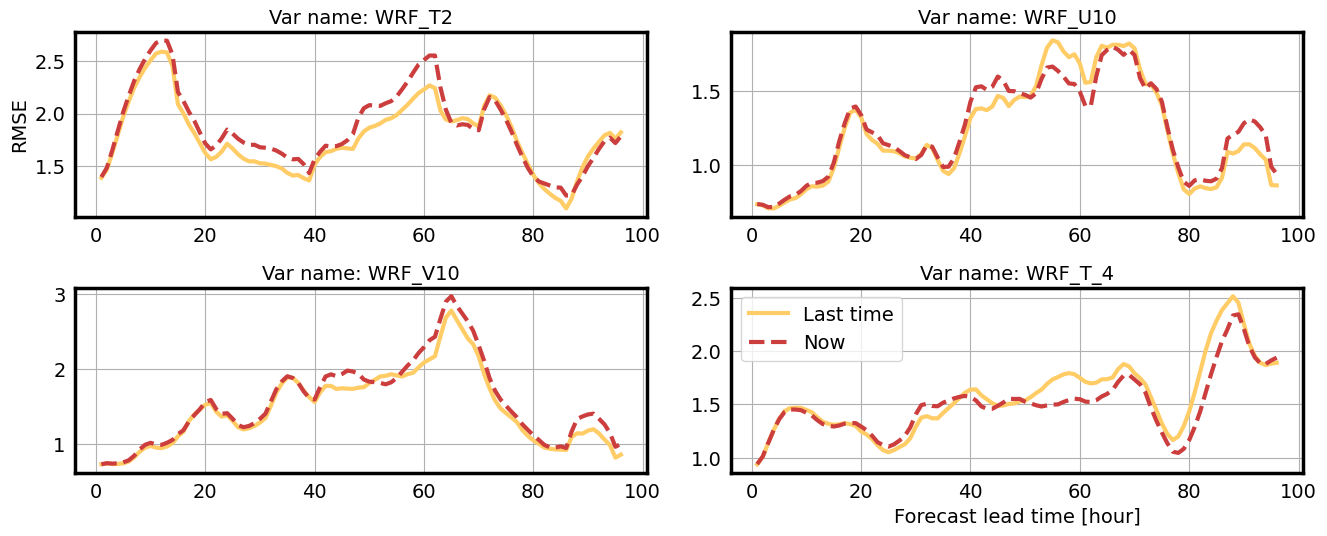

In [78]:
cut = 0
cut1 = 96

fig, axs = plt.subplots(2, 2, figsize=(13, 5))
AX = axs.ravel()
plt.tight_layout(w_pad=3, h_pad=3)

for i_var, varname in enumerate(varnames[:4]):
    ax = AX[i_var]
    ax = gu.ax_decorate_box(ax)
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=14)
    ax.grid(':')
    ax.plot(leads2[cut:cut1], dict_RMSE2[varname][cut:cut1], **line_keys['train'])
    ax.plot(leads1[cut:cut1], dict_RMSE[varname][cut:cut1], **line_keys['valid'])
    ax.set_title('Var name: {}'.format(varname), fontsize=14)
    
    if i_var == 0:
        ax.set_ylabel('RMSE', fontsize=14)
        
    if i_var == 3:
        ax.set_xlabel('Forecast lead time [hour]', fontsize=14)
        plt.legend(fontsize=14)

In [43]:
varname = 'WRF_T2'
print(np.mean((dict_RMSE[varname] - dict_RMSE2[varname])[:]))
varname = 'WRF_V10'
print(np.mean((dict_RMSE[varname] - dict_RMSE2[varname])[:]))
varname = 'WRF_U10'
print(np.mean((dict_RMSE[varname] - dict_RMSE2[varname])[:]))
varname = 'WRF_Q_tot_05_4'
print(np.mean((dict_RMSE[varname] - dict_RMSE2[varname])[:]))
varname = 'WRF_T_4'
print(np.mean((dict_RMSE[varname] - dict_RMSE2[varname])[:]))

-0.6553061108133723
-0.3527541628585813
-0.3242169817153005
-0.00455055084701446
-0.6534664659389381


In [79]:
varname = 'WRF_T2'
print(np.mean((dict_RMSE[varname] - dict_RMSE2[varname])[:]))
varname = 'WRF_V10'
print(np.mean((dict_RMSE[varname] - dict_RMSE2[varname])[:]))
varname = 'WRF_U10'
print(np.mean((dict_RMSE[varname] - dict_RMSE2[varname])[:]))
varname = 'WRF_Q_tot_05_4'
print(np.mean((dict_RMSE[varname] - dict_RMSE2[varname])[:]))
varname = 'WRF_T_4'
print(np.mean((dict_RMSE[varname] - dict_RMSE2[varname])[:]))

0.22713778222926329
0.10785082222144027
0.08969931394024624
0.0011071998640095038
0.2322466404860897


-0.10430704823310041

-0.09247716638396998

14.66990042167066

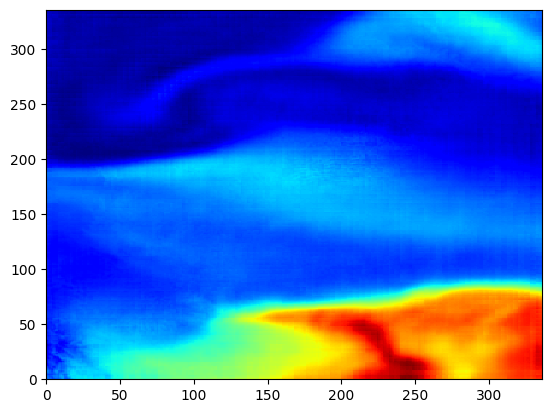

In [101]:
ds = xr.open_dataset('/glade/derecho/scratch/ksha/DWC/RAW_OUTPUT/CONUS_GP_ERA5/2020-01-01T00Z/pred_2020-01-01T00Z_001.nc')
WRF_T2 = ds['WRF_Q'].values
plt.pcolormesh(WRF_T2[0, -8, ...], cmap=plt.cm.jet)

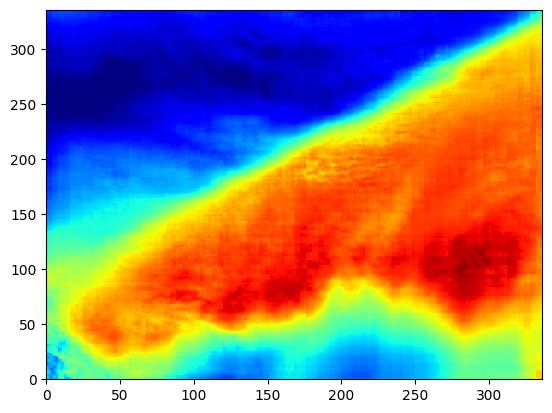

In [103]:
ds = xr.open_dataset('/glade/derecho/scratch/ksha/DWC/RAW_OUTPUT/CONUS_GP_ERA5/2020-01-01T00Z/pred_2020-01-01T00Z_8759.nc')
WRF_T2 = ds['WRF_Q'].values
plt.pcolormesh(WRF_T2[0, -8, ...], cmap=plt.cm.jet)